# 1. Propagating wave

Build a small two-dimensional tissue, stimulate one edge, and watch excitation travel to a recording point. By the end, you will have a **voltage map** of the tissue and an **action-potential trace** from one cell.

**Before you start:** select a Python kernel with Finitewave, the Aliev–Panfilov model plugin, NumPy, and Matplotlib installed. This tutorial uses the Numba CPU backend and requires no GPU. Run the cells from top to bottom; the first simulation includes compilation.

Aliev–Panfilov is a simple two-variable model of excitation and recovery. Its voltage `u` is dimensionless, and we label time in model units rather than milliseconds.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import finitewave as fw

## Create the tissue

`CardiacTissue` describes the spatial domain. We use a rectangular grid with 160 points along the direction of propagation and 40 across it. `dr` sets the spacing between neighboring points.

The recording point is halfway along the tissue, well away from the stimulated edge. Array coordinates are written as `[axis_0, axis_1]`.

In [2]:
shape = (160, 40)
dr = 0.25
recording_point = [shape[0] // 2, shape[1] // 2]

tissue = fw.CardiacTissue(shape, dr=dr)

## Stimulate one edge

A voltage stimulus sets `u` to `1` in the first five rows at time `5`. The delayed stimulus leaves a short resting segment in the recording. The coordinate bounds use grid indexes, with the upper bounds excluded.

Stimulating the full width launches an approximately planar wave along axis 0.

In [3]:
stimulus_time = 5.0
stimulus_width = 5

stimuli = fw.StimSequence()
stimuli.add_stim(fw.StimVoltageCoord(
    time=stimulus_time,
    volt_value=1.0,
    x_min=0, x_max=stimulus_width,
    y_min=0, y_max=shape[1],
))

## Record one cell

An `ActionPotentialTracker` stores voltage at a chosen grid point. Its `step=10` records every tenth simulation iteration. This reduces the amount of recorded data without changing the simulation time step.

Use the tracker's `tracking_times` when plotting: the recording interval need not equal the simulation time step.

In [4]:
action_potential = fw.ActionPotentialTracker(recording_point, step=10)
trackers = fw.TrackerSequence()
trackers.add_tracker(action_potential)

## Assemble and run the simulation

`CardiacSimulation` brings the components together:

| Component | Role |
| :--- | :--- |
| `cardiac_tissue` | Geometry and spatial grid |
| `cardiac_model` | Local excitation and recovery equations |
| `stim_sequence` | When and where to stimulate |
| `tracker_sequence` | What to record |

We choose `dt=0.01` and run until model time `50`. For this grid, Finitewave supplies its default spatial discretization and time integrator. One CPU thread keeps this introductory example's resource use modest.

In [5]:
simulation = fw.CardiacSimulation(dt=0.01, t_max=50.0, backend="numba")
simulation.cardiac_tissue = tissue
simulation.cardiac_model = fw.AlievPanfilov()
simulation.stim_sequence = stimuli
simulation.tracker_sequence = trackers

simulation.run(prog_bar=False, num_of_threads=1)
print(f"Completed {simulation.iteration} iterations at model time {simulation.t:.2f}.")

Completed 5000 iterations at model time 50.00.


## Plot the wave and the local response

The map shows the **final** voltage across the tissue. We transpose the array for display so axis 0, the direction of propagation, runs horizontally. The blue band marks the stimulus location; the white circle marks the recording point.

The trace shows voltage at that point throughout the run. The vertical line marks stimulus time, not the time the wave arrives at the recording point.

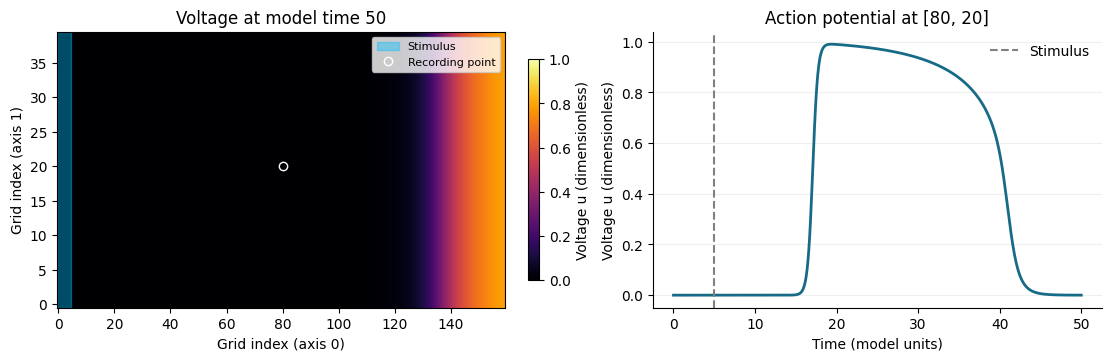

In [9]:
voltage = np.asarray(simulation.cardiac_model.u)
times = np.asarray(action_potential.tracking_times)
trace = np.asarray(action_potential.output).reshape(-1)

fig, (map_ax, trace_ax) = plt.subplots(
    1, 2, figsize=(11, 3.5), layout="constrained",
)
image = map_ax.imshow(
    voltage.T, origin="lower", cmap="inferno", vmin=0, vmax=1,
    aspect="auto",
)
map_ax.axvspan(-0.5, stimulus_width - 0.5, color="deepskyblue", alpha=0.4,
               label="Stimulus")
map_ax.plot(*recording_point, "o", markerfacecolor="none",
            markeredgecolor="white", label="Recording point")
map_ax.set(
    title=f"Voltage at model time {simulation.t:.0f}",
    xlabel="Grid index (axis 0)", ylabel="Grid index (axis 1)",
)
map_ax.legend(loc="upper right", fontsize=8)
fig.colorbar(image, ax=map_ax, label="Voltage u (dimensionless)", shrink=0.8)

trace_ax.plot(times, trace, color="#176b87", linewidth=2)
trace_ax.axvline(stimulus_time, color="0.5", linestyle="--", label="Stimulus")
trace_ax.set(
    title=f"Action potential at {recording_point}",
    xlabel="Time (model units)", ylabel="Voltage u (dimensionless)",
)
trace_ax.spines[["top", "right"]].set_visible(False)
trace_ax.grid(axis="y", alpha=0.2)
trace_ax.legend(frameon=False)
plt.show()

## Try a small change

- Move `recording_point` farther from the stimulated edge and compare the delay before excitation.
- Change `stimulus_time` from `5` to `10` and observe how the response shifts.
- Increase `t_max` to see more of the recovery phase.

After a change, rerun from the tissue-creation cell so that the model, stimulus, and tracker are rebuilt together. Keep `dt` and `dr` unchanged for these first experiments.

To explore other equations, see [Finitewave template models](../Guides/FinitewaveTemplateModels.ipynb). For parameter customization, continue to [Configuring models](../Guides/ConfiguringModels.ipynb).